## Необходимые импорты

In [72]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize
from sklearn.metrics import r2_score, mean_squared_error

from src.compressor import DCS
from src.fluid import Fluid
from src.interpolator import LinearInterpolator
from src.pipe import Pipe
from src.reservoir import ResProps, Reservoir
from src.simulator import FieldSimulator
from src.state import NodeState
from src.well import Well

## Исходные данные

### Пласт (общий для всех трёх скважин)

| Параметр | Обозначение | Значение | Ед. изм. |
|----------|-------------|----------|----------|
| Начальное пластовое давление | $P_{res}^{(0)}$ | 100 | атм |
| Объём пласта | $V_{res}$ | $\pi \cdot 500^2 \cdot 25$ | м³ |
| Пластовая температура | $T_{res}$ | 310 | К |

---

### Скважины (три, с разными траекториями)

| Параметр | Обозначение | Скважина 1 | Скважина 2 | Скважина 3 | Ед. изм. |
|----------|-------------|:----------:|:----------:|:----------:|----------|
| Проницаемость | $k_i$ | 50 | 50 | 50 | мД |
| Эффективная мощность | $h_i$ | 25 | 25 | 25 | м |
| Радиус контура питания | $r_{e,i}$ | 500 | 500 | 500 | м |
| Радиус скважины | $r_{w,i}$ | 0.1 | 0.1 | 0.1 | м |
| Длина по стволу | $L_i$ | 2000 | 2500 | 1800 | м |
| Вертикальная глубина | $H_i$ | 1800 | 1900 | 1600 | м |
| Диаметр НКТ | $D_i$ | 0.062 | 0.062 | 0.073 | м |
| Шероховатость | $\delta_i$ | 0.000046 | 0.000046 | 0.000046 | м |

---

### Шлейф (от куста до ДКС)

| Параметр | Обозначение | Значение | Ед. изм. |
|----------|-------------|----------|----------|
| Длина | $L_s$ | 5000 | м |
| Диаметр | $D_s$ | 0.200 | м |
| Шероховатость | $\delta_s$ | 0.000046 | м |

---

### ДКС и граничные условия

| Параметр | Обозначение | Значение | Ед. изм. |
|----------|-------------|----------|----------|
| Давление в магистрали | $P_{line}$ | 5 | атм |
| Степень сжатия (начальная) | $CR$ | 1.5 | — |
| Сторонний газ (начальный) | $q_{ext}$ | 500 | ст.м³/сут |

---


In [10]:
# для удобства я присвою значения параметрам

P_res_0 = 100.0                     # Начальное пластовое давление, атм
V_res   = math.pi * 500 ** 2 * 25   # Объём пласта, м³
T_res   = 310.0                     # Пластовая температура, К

wells_data = {
    'k'    : [50.0, 50.0, 50.0],          # Проницаемость, мД
    'h'    : [25.0, 25.0, 25.0],          # Эффективная мощность, м
    're'   : [500.0, 500.0, 500.0],       # Радиус контура питания, м
    'rw'   : [0.1, 0.1, 0.1],             # Радиус скважины, м
    'L'    : [2000.0, 2500.0, 1800.0],    # Длина по стволу, м
    'H'    : [1800.0, 1900.0, 1600.0],    # Вертикальная глубина, м
    'D'    : [0.062, 0.062, 0.073],       # Диаметр НКТ, м
    'delta': [0.000046, 0.000046, 0.000046] # Шероховатость стенок, м
}

shlyf_data = {
    'L'    : 5000.0,          # Длина, м
    'D'    : 0.200,           # Диаметр, м
    'delta': 0.000046         # Шероховатость, м
}

P_line = 5.0       # Давление в магистральном газопроводе, атм
CR     = 1.5       # Степень сжатия ДКС (начальная)
q_ext  = 500.0     # Расход стороннего газа на манифольде, ст.м³/сут

print(f"Пласт: P_res_0 = {P_res_0} атм | V_res = {V_res:.2f} м³ | T_res = {T_res} К")
print(f"Скважины: {len(wells_data['k'])} шт.")
print(f"Шлейф: L = {shlyf_data['L']} м | D = {shlyf_data['D']} м")
print(f"Граница: P_line = {P_line} атм | CR = {CR} | q_ext = {q_ext} ст.м³/сут")

Пласт: P_res_0 = 100.0 атм | V_res = 19634954.08 м³ | T_res = 310.0 К
Скважины: 3 шт.
Шлейф: L = 5000.0 м | D = 0.2 м
Граница: P_line = 5.0 атм | CR = 1.5 | q_ext = 500.0 ст.м³/сут


In [12]:
# загрузка и проверка датасетов
df_visc = pd.read_csv('interp_data.csv', sep=';')
print("Список столбцов:", df_visc.columns.tolist())
display(df_visc.head())

Список столбцов: ['pressure, atm', 'viscosity, cP']


,"pressure, atm","viscosity, cP"
0,1.000000,0.018312
1,3.010101,0.018321
2,5.020202,0.018330
3,7.030303,0.018339
4,9.040404,0.018349


In [13]:
df_fluid = pd.read_csv('hw2_data.csv', sep=';')
print("Список столбцов:", df_fluid.columns.tolist())
display(df_fluid.head())

Список столбцов: ['Unnamed: 0', 'student', 'xa, mol. %', 'xy, mol. %', 'rho_c, kg/m3']


,Unnamed: 0,student,"xa, mol. %","xy, mol. %","rho_c, kg/m3"
0,0,Али Иван,0.3745,0.9507,0.6799
1,1,Альзейн Мохаммад Альжавад,0.7320,0.5987,0.6799
2,2,Андреев Вячеслав Олегович,0.1560,0.1560,0.6799
3,3,Гедымин Герман Константинович,0.0581,0.8662,0.6799
4,4,Инюхин Дмитрий Романович,0.6011,0.7081,0.6799


In [14]:
df_adapt = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')
print("Список столбцов:", df_adapt.columns.tolist())
display(df_adapt.head())

Список столбцов: ['well', 'date', 'q', 'p_res', 'p_bhp', 'p_thp']


,well,date,q,p_res,p_bhp,p_thp
0,1013,01.08.1900,62290,8.0709,5.3740,3.7756
1,1013,01.08.1900,30149,8.0709,6.9235,6.2076
2,1013,01.08.1900,43520,8.0709,6.3057,5.2269
3,1013,01.08.1900,66510,8.0709,5.0995,3.2852


In [15]:
# выведу индивидуальные параметры и создам объект Fluid
my_row = df_fluid.iloc[2]
print(f"{my_row['student']}")
print(f"xa (N₂) = {my_row['xa, mol. %']}%")
print(f"xy (CO₂) = {my_row['xy, mol. %']}%")
print(f"ρ_c = {my_row['rho_c, kg/m3']} кг/м³")

# для объекта понадобится молярная масса смеси
M_CH4, M_N2, M_CO2 = 16.04, 28.0135, 44.01  # кг/кмоль
xa = my_row['xa, mol. %'] / 100
xy = my_row['xy, mol. %'] / 100
xe = 1 - xa - xy
M = xe * M_CH4 + xa * M_N2 + xy * M_CO2
print(f'\nМолярная масса смеси: {M:.5f}')

Андреев Вячеслав Олегович
xa (N₂) = 0.156%
xy (CO₂) = 0.156%
ρ_c = 0.6799 кг/м³

Молярная масса смеси: 16.10231


## PVT-модель

In [16]:
# создание объекта Fluid
fluid = Fluid(M=M, rho_c=my_row['rho_c, kg/m3'], xa=xa, xy=xy, T=T_res)

''' Инициализируем интерполятор вязкости:
  - cоздаётся экземпляр LinearInterpolator;
  - проверяется сортировка по давлению;
  - сохраняется в атрибут self._mu_interpolator;
  - начало работы fluid.mu(P)
'''
fluid.set_viscosity_data(
    df_visc['pressure, atm'].tolist(),
    df_visc['viscosity, cP'].tolist()
)

In [17]:
# диапазон давлений для графиков по условию
P_range = np.linspace(1, 200, 200)

# расчёт свойств
Z_vals = [fluid.z(P) for P in P_range]
Bg_vals = [fluid.bg(P) for P in P_range]
mu_vals = [fluid.mu(P) for P in P_range]
rho_real = [fluid.ro(P) for P in P_range]

# рассчитаем плотность идеального газа для сравнения: ρ = P·M / (R·T)
R = 8.314  # универсальная газовая постоянная, Дж/(моль·К)
rho_ideal = [(P * 101325 * M) / (R * 1000 * T_res) for P in P_range]

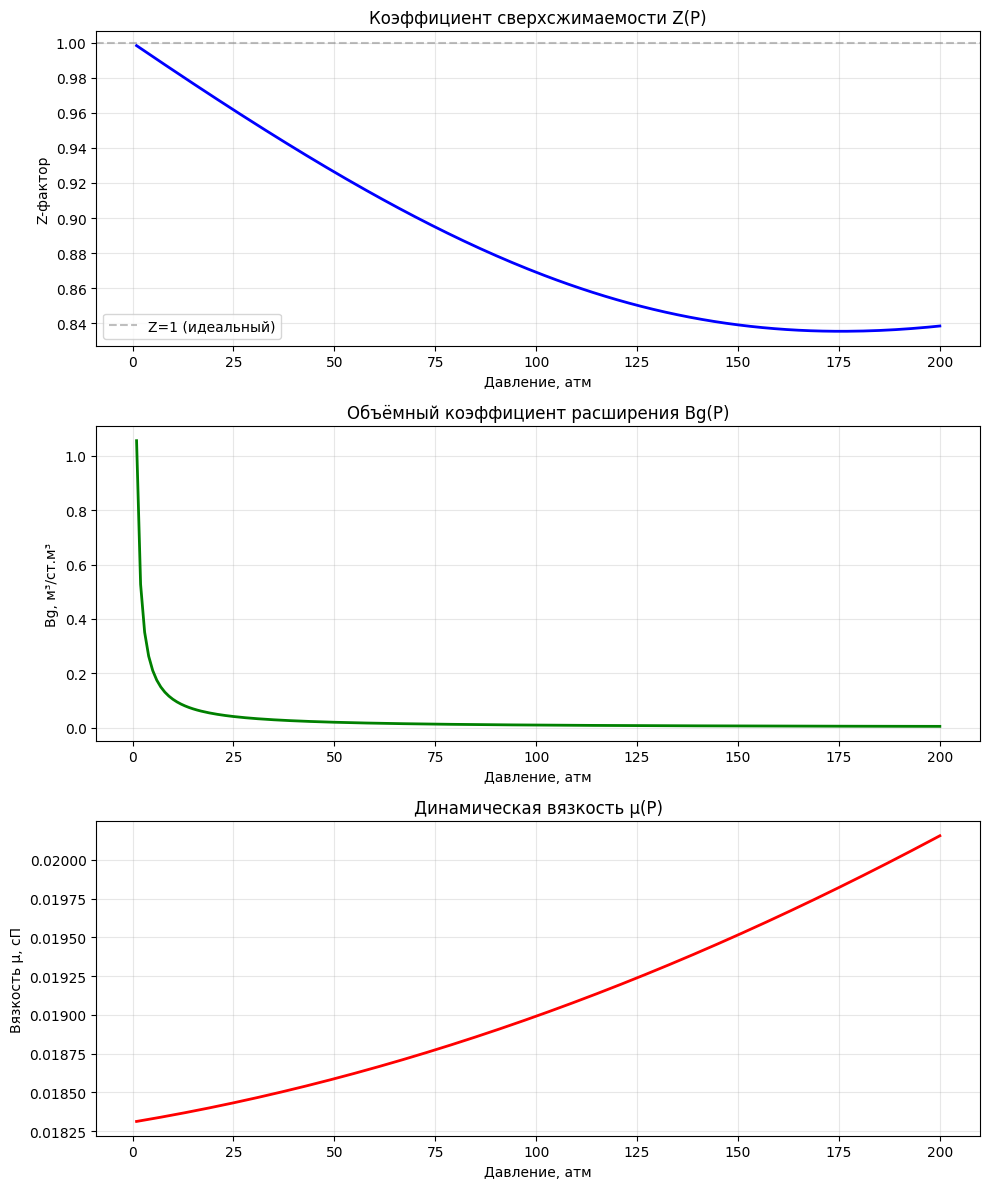

In [18]:
# построение графиков Z(P), Bg(P), μ(P)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Z(P)
axes[0].plot(P_range, Z_vals, 'b-', linewidth=2)
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Z=1 (идеальный)')
axes[0].set_xlabel('Давление, атм')
axes[0].set_ylabel('Z-фактор')
axes[0].set_title('Коэффициент сверхсжимаемости Z(P)')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Bg(P)
axes[1].plot(P_range, Bg_vals, 'g-', linewidth=2)
axes[1].set_xlabel('Давление, атм')
axes[1].set_ylabel('Bg, м³/ст.м³')
axes[1].set_title('Объёмный коэффициент расширения Bg(P)')
axes[1].grid(alpha=0.3)

# μ(P)
axes[2].plot(P_range, mu_vals, 'r-', linewidth=2)
axes[2].set_xlabel('Давление, атм')
axes[2].set_ylabel('Вязкость μ, сП')
axes[2].set_title('Динамическая вязкость μ(P)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

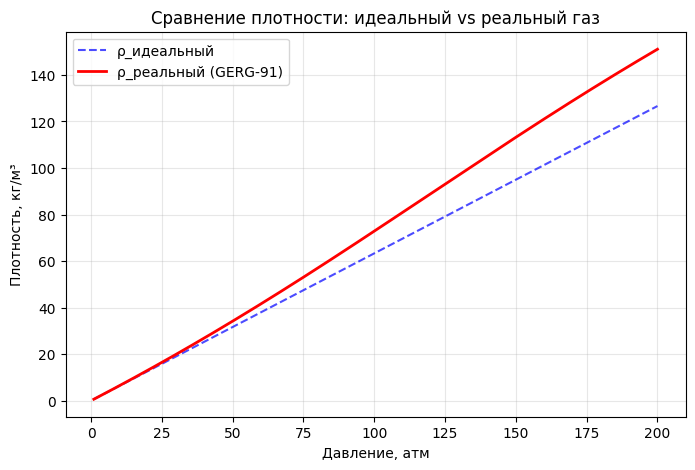

In [19]:
# сравнение ρ_ideal vs ρ_real
plt.figure(figsize=(8, 5))
plt.plot(P_range, rho_ideal, 'b--', label='ρ_идеальный', alpha=0.7)
plt.plot(P_range, rho_real, 'r-', label='ρ_реальный (GERG-91)', linewidth=2)
plt.xlabel('Давление, атм')
plt.ylabel('Плотность, кг/м³')
plt.title('Сравнение плотности: идеальный vs реальный газ')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [20]:
# таблица контрольных точек
# === Таблица контрольных точек ===
print("Контрольные значения PVT-свойств:")
print(f"{'P, атм':<10} {'Z':<8} {'Bg':<12} {'ρ, кг/м³':<12} {'μ, сП':<10}")
print("-"*60)
# Расширенный список давлений для более детальной таблицы
P_tests = [1, 2, 5, 10, 15, 25, 50, 100, 150, 200]

for P_test in P_tests:
    z = fluid.z(P_test)
    bg = fluid.bg(P_test)
    rho = fluid.ro(P_test)
    mu = fluid.mu(P_test)
    print(f"{P_test:<10} {z:<8.4f} {bg:<12.6f} {rho:<12.2f} {mu:<10.6f}")

Контрольные значения PVT-свойств:
P, атм     Z        Bg           ρ, кг/м³     μ, сП     
------------------------------------------------------------
1          0.9984   1.055823     0.63         0.018312  
2          0.9969   0.527085     1.27         0.018316  
5          0.9922   0.209845     3.19         0.018330  
10         0.9845   0.104105     6.43         0.018354  
15         0.9768   0.068864     9.72         0.018379  
25         0.9618   0.040682     16.46        0.018432  
50         0.9263   0.019590     34.17        0.018588  
100        0.8690   0.009190     72.85        0.018991  
150        0.8390   0.005915     113.18       0.019515  
200        0.8383   0.004433     151.02       0.020155  


## Модель пласта

In [21]:
# расчеты этого пункта нужно будет проводить по одной скважине
idx = 0  # индекс скважины 1

k = wells_data['k'][idx]
h = wells_data['h'][idx]
re = wells_data['re'][idx]
rw = wells_data['rw'][idx]
L_tubing = wells_data['L'][idx]
D_tubing = wells_data['D'][idx]
delta_tubing = wells_data['delta'][idx]
H_tubing = wells_data['H'][idx]

print(f"Скважина {idx+1}:")
print(f"k = {k} мД, h = {h} м, re = {re} м, rw = {rw} м")
print(f"НКТ: L = {L_tubing} м, D = {D_tubing} м, H = {H_tubing} м")

Скважина 1:
k = 50.0 мД, h = 25.0 м, re = 500.0 м, rw = 0.1 м
НКТ: L = 2000.0 м, D = 0.062 м, H = 1800.0 м


In [22]:
# создаю объект НКТ для скважины
# Для IPR кривой нам пока не нужен точный расчёт гидравлики,
# но объект должен существовать для архитектуры
pipe_well = Pipe(
    L=L_tubing,
    D=D_tubing,
    roughness=delta_tubing,
    fluid=fluid,
    vertical_depth=H_tubing,
    name=f"well_{idx+1}_tubing"
)

# создаю объект скважны
well = Well(
    fluid=fluid,
    k=k, h=h, re=re, rw=rw,
    pipe=pipe_well
)

# расчет коэффициента продуктивности C при P_res = 100 атм ===
P_res = P_res_0
C = well.get_productivity_index(P_res)
mu_at_Pres = fluid.mu(P_res)

print(f"Коэффициент продуктивности при P_res = {P_res} атм:")
print(f"μ({P_res} атм) = {mu_at_Pres:.6f} сП")
print(f"Формула: C = (β·k·h) / (μ·ln(re/rw))")
print(f"= (0.00852702·{k}·{h}) / ({mu_at_Pres:.6f}·ln({re}/{rw}))")
print(f"C = {C:.4f} ст.м³/(сут·атм)")

Коэффициент продуктивности при P_res = 100.0 атм:
μ(100.0 атм) = 0.018991 сП
Формула: C = (β·k·h) / (μ·ln(re/rw))
= (0.00852702·50.0·25.0) / (0.018991·ln(500.0/0.1))
C = 65.8964 ст.м³/(сут·атм)


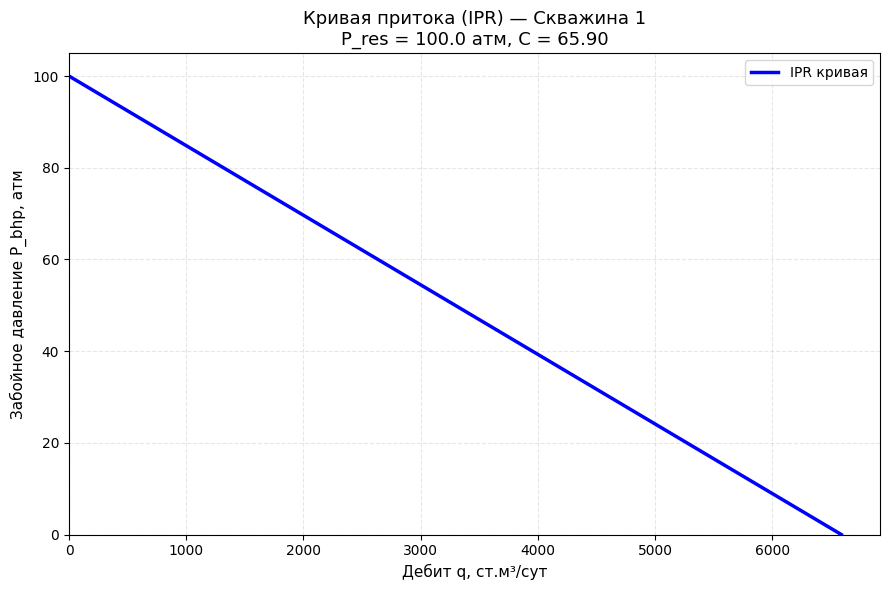

In [23]:
# построение кривой IPR
# P_bhp меняется от 0 до P_res (максимальный перепад -> максимальный дебит)
pbhp_range = np.linspace(0, P_res, 100)
q_ipr = [well.q(P_res, pbhp) for pbhp in pbhp_range]

plt.figure(figsize=(9, 6))
plt.plot(q_ipr, pbhp_range, 'b-', linewidth=2.5, label='IPR кривая')
plt.xlabel('Дебит q, ст.м³/сут', fontsize=11)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=11)
plt.title(f'Кривая притока (IPR) — Скважина {idx+1}\nP_res = {P_res} атм, C = {C:.2f}',
          fontsize=13)

plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [24]:
# таблица контрольных значений
print(f"Контрольные точки кривой IPR:")
print(f"{'P_bhp, атм':<12} {'q, ст.м³/сут':<15} {'ΔP = P_res-P_bhp':<18}")
print("-"*45)
for pbhp_test in [0, 20, 40, 60, 80, 90, 100]:
    q_test = well.q(P_res, pbhp_test)
    dp = P_res - pbhp_test
    print(f"{pbhp_test:<12} {q_test:<15.1f} {dp:<18.1f}")

Контрольные точки кривой IPR:
P_bhp, атм   q, ст.м³/сут    ΔP = P_res-P_bhp  
---------------------------------------------
0            6589.6          100.0             
20           5271.7          80.0              
40           3953.8          60.0              
60           2635.9          40.0              
80           1317.9          20.0              
90           659.0           10.0              
100          0.0             0.0               


## Гидравлика

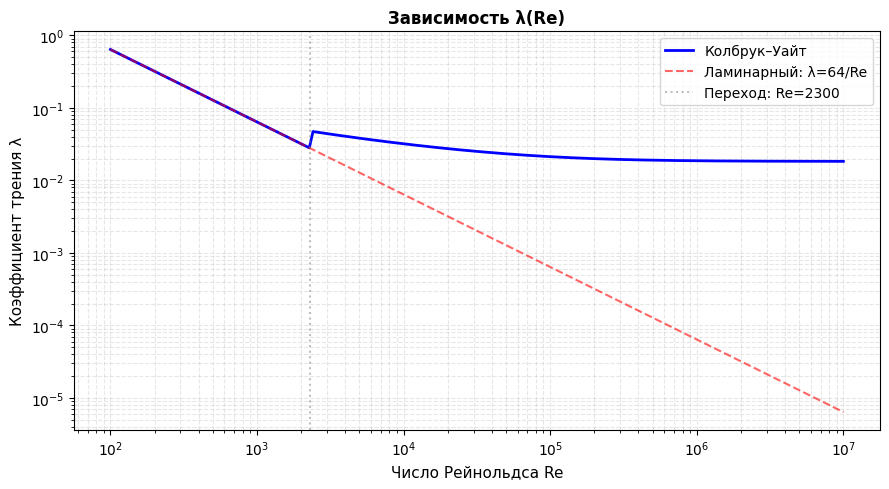

In [26]:
# зависимость λ(Re) по Колбруку–Уайту
# параметры для теста на основе скважины 1
D_test = wells_data['D'][0]
delta_test = wells_data['delta'][0]
rel_rough = delta_test / D_test

Re_range = np.logspace(2, 7, 200)  # диапазон чисел Рейнольдса от 100 до 10 млн
lambda_vals = []
for Re in Re_range:
    lam = pipe_well._calc_lambda(Re, rel_rough)
    lambda_vals.append(lam)

# построение графика λ(Re)
plt.figure(figsize=(9, 5))
plt.loglog(Re_range, lambda_vals, 'b-', linewidth=2, label='Колбрук–Уайт')
# линия ламинарного режима для сравнения
plt.loglog(Re_range, [64/Re for Re in Re_range], 'r--', alpha=0.6, label='Ламинарный: λ=64/Re')
# вертикальная линия перехода
plt.axvline(x=2300, color='gray', linestyle=':', alpha=0.5, label='Переход: Re=2300')

plt.xlabel('Число Рейнольдса Re', fontsize=11)
plt.ylabel('Коэффициент трения λ', fontsize=11)
plt.title(f'Зависимость λ(Re)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
# контрольные точки
print(f"{'Re':<12} {'λ (расчёт)':<15} {'Режим':<12}")
print("-"*40)
for Re_test in [500, 2000, 2250, 2300, 2350, 1e4, 1e5, 1e6]:
    lam_test = pipe_well._calc_lambda(Re_test, rel_rough)
    regime = "Ламинарный" if Re_test < 2300 else "Турбулентный"
    print(f"{Re_test:<12.0f} {lam_test:<15.5f} {regime:<12}")

Re           λ (расчёт)      Режим       
----------------------------------------
500          0.12800         Ламинарный  
2000         0.03200         Ламинарный  
2250         0.02844         Ламинарный  
2300         0.04788         Турбулентный
2350         0.04756         Турбулентный
10000        0.03200         Турбулентный
100000       0.02127         Турбулентный
1000000      0.01867         Турбулентный


In [28]:
# расчет давления на манифольде
# создаём симулятор для расчёта
reservoir_temp = Reservoir(ResProps(P=100.0, V=V_res, T=T_res), fluid)

wells_temp = []
for i in range(3):
    pipe = Pipe(
        L=wells_data['L'][i],
        D=wells_data['D'][i],
        roughness=wells_data['delta'][i],
        fluid=fluid,
        vertical_depth=wells_data['H'][i],
        name=f"well_{i+1}_temp"
    )
    wells_temp.append(Well(fluid=fluid, k=wells_data['k'][i], h=wells_data['h'][i],
                           re=wells_data['re'][i], rw=wells_data['rw'][i], pipe=pipe))

shlyf_temp = Pipe(L=shlyf_data['L'], D=shlyf_data['D'], roughness=shlyf_data['delta'],
                  fluid=fluid, vertical_depth=0.0, name="shlyf_temp")
dcs_temp = DCS(CR=CR, P_line=P_line, q_ext=q_ext)

sim_temp = FieldSimulator(reservoir=reservoir_temp, wells=wells_temp,
                          shlyf=shlyf_temp, dcs=dcs_temp)

states = sim_temp.solve(P_res=100.0)
P_man = states['well_1'].P_out  # P_man общее для всех скважин

q_total = sum(states[f'well_{i+1}'].q_std for i in range(3))

print(f"P_man из solve() = {P_man:.4f} атм")
print(f"q_total = {q_total:.4f} ст.м³/сут")

P_man из solve() = 3.3619 атм
q_total = 18953.5429 ст.м³/сут


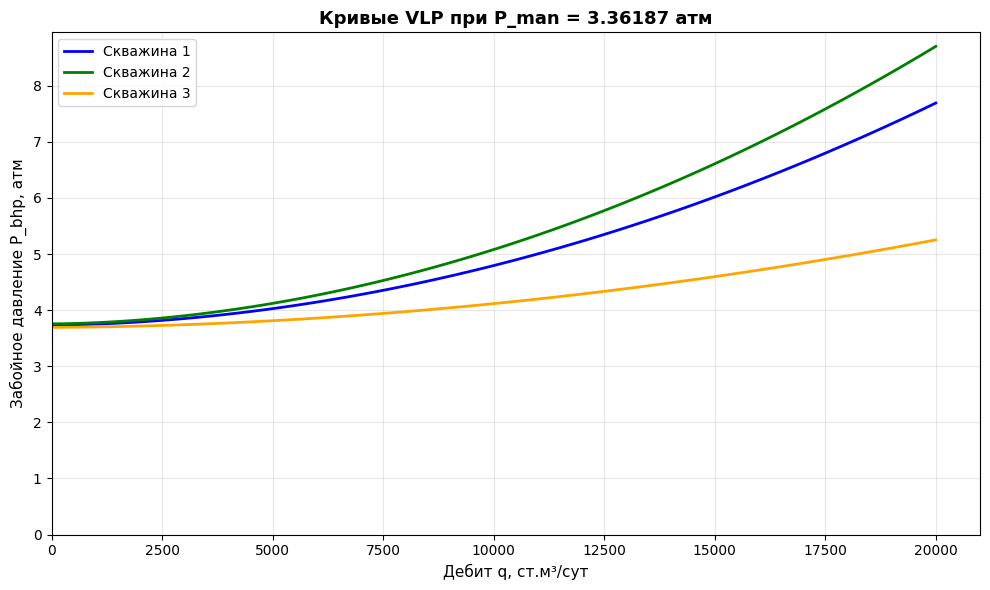

In [29]:
# кривые VLP для трёх скважин
q_range = np.linspace(0, 20000, 100)  # диапазон дебитов для VLP 0–20 тыс. ст.м³/сут
vlp_results = {}

plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'orange']

for idx in range(3):
    pipe = Pipe(
        L=wells_data['L'][idx],
        D=wells_data['D'][idx],
        roughness=wells_data['delta'][idx],
        fluid=fluid,
        vertical_depth=wells_data['H'][idx],
        name=f"well_{idx+1}_vlp"
    )
    qs, pbhps = pipe.get_vlp(P_man, q_range.tolist())
    vlp_results[f'well_{idx+1}'] = (qs, pbhps)
    plt.plot(qs, pbhps, color=colors[idx], linewidth=2, label=f'Скважина {idx+1}')

plt.xlabel('Дебит q, ст.м³/сут', fontsize=11)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=11)
plt.title(f'Кривые VLP при P_man = {P_man:.5f} атм', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

```text
Скважины → [Манифолд] → [Шлейф] → [ДКС] → [Магистраль]
            P_man      P_in      P_out     P_in      P_out
                     = P_man   = P_in    = P_line
                                DCS

Проведу расчёт давлений от конца к началу:
Магистраль: P_line = 5 атм (фиксировано по условию)
ДКС выход: P_out_DCS = P_line = 5 атм
ДКС вход: P_in_DCS = P_out_DCS / CR = 5 / 1.5 = 3.333 атм (1.5 - степень сжатия по условию)
Шлейф выход: P_out_shlyf = P_in_DCS = 3.333 атм
Шлейф вход = Манифольд: P_in_shlyf = P_man ≈ 3.36 атм (из solve())
Потери в шлейфе: ΔP_shlyf = P_man - P_out_shlyf ≈ 0.03 атм

P_out_DCS (магистраль) = 5.00000 атм
P_in_DCS = P_line / CR = 3.33333 атм
P_out_shlyf = P_in_DCS = 3.33333 атм
q_total = 18953.54286 ст.м³/сут
P_man (из графика) = 3.36187 атм
ΔP_shlyf = 0.02854 атм


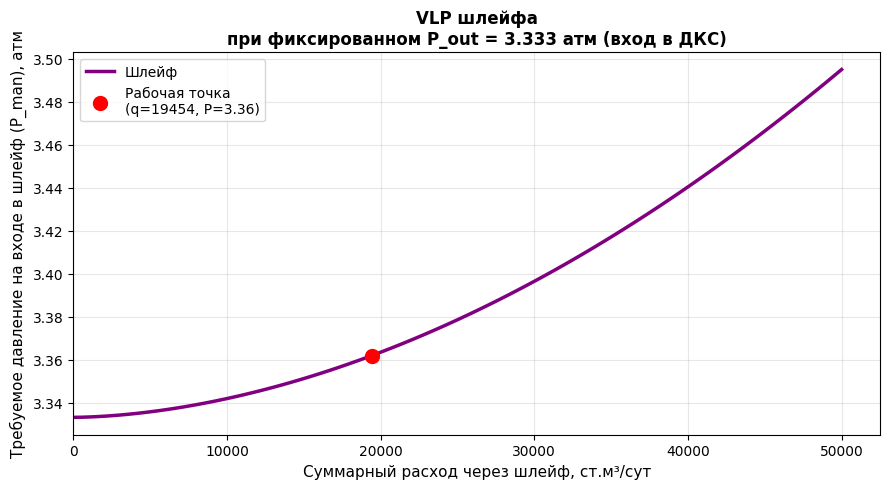

In [30]:
# граничные давления для шлейфа
P_out_DCS = P_line
P_in_DCS = P_out_DCS / CR
P_out_shlyf = P_in_DCS
q_total_actual = q_total + q_ext
p_man_actual = P_man

shlyf_pipe = Pipe(
    L=shlyf_data['L'],
    D=shlyf_data['D'],
    roughness=shlyf_data['delta'],
    fluid=fluid,
    vertical_depth=0.0,  # горизонтальный
    name="shlyf_vlp"
)

q_range_shlyf = np.linspace(0, 50000, 100) # диапазон расходов через шлейф

# get_vlp(P_man=...) считает P_in = P_man + потери
# для шлейфа: P_man в аргументе = P_out_shlyf (выходное давление)
qs_shlyf, p_in_required = shlyf_pipe.get_vlp(P_man=P_out_shlyf, q_values=q_range_shlyf.tolist())

print(f"P_out_DCS (магистраль) = {P_out_DCS:.5f} атм")
print(f"P_in_DCS = P_line / CR = {P_in_DCS:.5f} атм")
print(f"P_out_shlyf = P_in_DCS = {P_out_shlyf:.5f} атм")
print(f"q_total = {q_total:.5f} ст.м³/сут")
print(f"P_man (из графика) = {p_man_actual:.5f} атм")
print(f"ΔP_shlyf = {p_man_actual - P_out_shlyf:.5f} атм")

# построение графика
plt.figure(figsize=(9, 5))
plt.plot(qs_shlyf, p_in_required, 'purple', linewidth=2.5, label='Шлейф')

# рабочая точка
plt.scatter([q_total_actual], [p_man_actual],
            c='red', s=100, zorder=5,
            label=f'Рабочая точка\n(q={q_total_actual:.0f}, P={p_man_actual:.2f})')

plt.xlabel('Суммарный расход через шлейф, ст.м³/сут', fontsize=11)
plt.ylabel('Требуемое давление на входе в шлейф (P_man), атм', fontsize=11)
plt.title(f'VLP шлейфа\nпри фиксированном P_out = {P_out_shlyf:.3f} атм (вход в ДКС)',
          fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

Кривая VLP показывает, какое давление нужно на манифольде, чтобы преодолеть гидравлические потери при данном расходе, а рабочая точка соответствует фактическому расходу

## Рабочая точка

IPR (Inflow): Показывает, сколько газа может отдать пласт при данном забойном давлении.

VLP (Outflow): Показывает, какое забойное давление нужно создать, чтобы поднять этот газ на поверхность (преодолеть трение и гидростатику) при фиксированном давлении на манифольде.

Точка пересечения - это и есть рабочая точка. В ней способности пласта отдать газ совпадают со способностями трубы этот газ вынести.

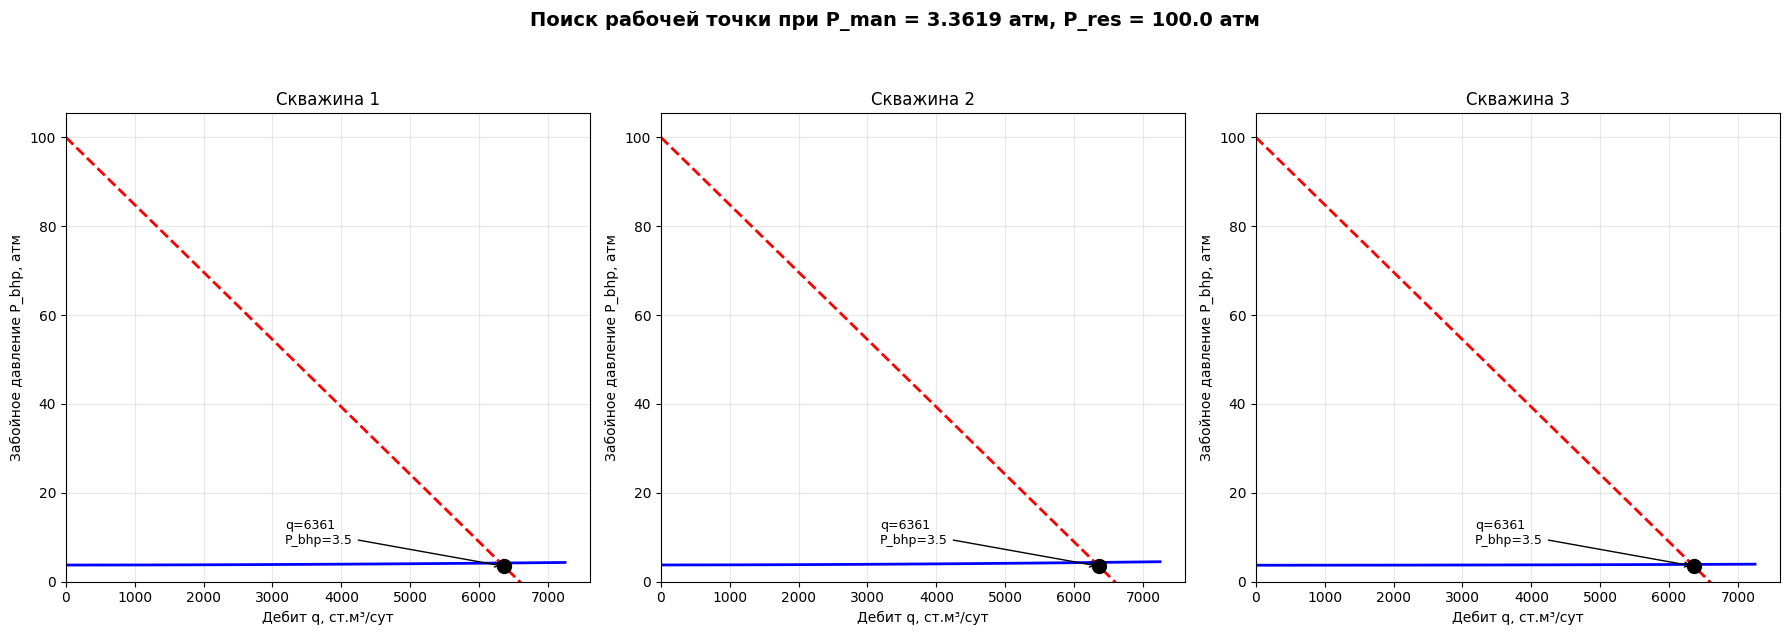

In [31]:
# используем давление манифольда, которое мы обосновали ранее
P_man_operating = 3.36  # атм
P_res = 100.0           # атм (пластовое)

# 3 скважины, поэтому создаем три сабплота
# для построения понадобятся пластовое давление и давление на манифольде, рассчитанные ранее
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Поиск рабочей точки при P_man = {P_man:.4f} атм, P_res = {P_res_0} атм',
             fontsize=14, fontweight='bold', y=1.05)

colors = ['blue', 'green', 'orange']
well_names = ['Скважина 1', 'Скважина 2', 'Скважина 3']

results_summary = []

for idx in range(3):
    ax = axes[idx]

    # параметры текущей скважины
    k = wells_data['k'][idx]
    h = wells_data['h'][idx]
    re = wells_data['re'][idx]
    rw = wells_data['rw'][idx]
    L = wells_data['L'][idx]
    D = wells_data['D'][idx]
    H = wells_data['H'][idx]
    delta = wells_data['delta'][idx]

    # создание объектов
    well_obj = Well(fluid=fluid, k=k, h=h, re=re, rw=rw, pipe=None)
    pipe_obj = Pipe(L=L, D=D, roughness=delta, fluid=fluid, vertical_depth=H)

    # расчёт кривой IPR (P_bhp от q)
    # IPR: q = C * (P_res - P_bhp) => P_bhp = P_res - q / C
    C = well_obj.get_productivity_index(P_res_0)

    # генерируем дебиты от 0 до максимума с небольшим запасом
    q_max_ipr = C * P_res_0
    q_range = np.linspace(0, q_max_ipr * 1.1, 50)

    pbhp_ipr = [P_res_0 - q / C for q in q_range]

    # расчёт кривой VLP (P_bhp от q)
    # VLP: P_bhp = P_man + dP(q)
    q_range_vlp = q_range # используем тот же диапазон
    qs_vlp, pbhp_vlp = pipe_obj.get_vlp(P_man, q_range_vlp.tolist())

    # построение графиков
    ax.plot(q_range, pbhp_ipr, 'r--', linewidth=2, label='IPR (Приток)')
    ax.plot(qs_vlp, pbhp_vlp, 'b-', linewidth=2, label='VLP (Подъём)')

    # поиск точки пересечения
    # находим индекс, где разница между кривыми минимальна
    diff = np.abs(np.array(pbhp_ipr) - np.array(pbhp_vlp))
    intersection_idx = np.argmin(diff)

    q_working = q_range[intersection_idx]
    p_bhp_working = pbhp_ipr[intersection_idx]

    # отмечаем точку
    ax.plot(q_working, p_bhp_working, 'ko', markersize=10, zorder=5, label='Рабочая точка')
    ax.annotate(f'q={q_working:.0f}\nP_bhp={p_bhp_working:.1f}',
                xy=(q_working, p_bhp_working), xytext=(q_working*0.5, p_bhp_working+5),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

    ax.set_title(well_names[idx])
    ax.set_xlabel('Дебит q, ст.м³/сут')
    ax.set_ylabel('Забойное давление P_bhp, атм')
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    results_summary.append({
        'Well': well_names[idx],
        'q_work': q_working,
        'P_bhp': p_bhp_working,
        'C': C
    })

plt.tight_layout()
plt.show()

In [32]:
# вывод таблицы результатов
print(f"{'Скважина':<12} | {'C, м³/(сут·атм)':<15} | {'q_раб, ст.м³/сут':<15} | {'P_bhp, атм':<10}")
print("-" * 60)
total_q = 0
for res in results_summary:
    print(f"{res['Well']:<12} | {res['C']:<15.2f} | {res['q_work']:<15.1f} | {res['P_bhp']:<10.2f}")
    total_q += res['q_work']

print(f"\nСуммарный дебит куста: {total_q:.1f} ст.м³/сут")
print(f"(Для сравнения: solve() выдал ~18953 ст.м³/сут)")

Скважина     | C, м³/(сут·атм) | q_раб, ст.м³/сут | P_bhp, атм
------------------------------------------------------------
Скважина 1   | 65.90           | 6361.0          | 3.47      
Скважина 2   | 65.90           | 6361.0          | 3.47      
Скважина 3   | 65.90           | 6361.0          | 3.47      

Суммарный дебит куста: 19083.1 ст.м³/сут
(Для сравнения: solve() выдал ~18953 ст.м³/сут)


Рабочая точка скважины определяется пересечением кривой притока из пласта (IPR) и кривой подъёма по НКТ (VLP). Поскольку параметры пласта (k, h, r_e, r_w) для всех трёх скважин в задании идентичны, кривые IPR полностью совпадают. При низком рабочем давлении плотность газа мала, поэтому потери в стволе невелики, а кривые VLP практически горизонтальны. Это приводит к схожим рабочим дебитам (~6360 ст.м³/сут на скважину). Можно заметить небольшое расхождение суммарного дебита с численным решением. Это связано с тем, что fsolve ищет пересечение аналитически, а здесь мы берём ближайшую точку на сетке из 50 значений. Погрешность 0.7% — отличный результат для графического метода.


## Динамика

In [33]:
# сборка системы
# создаем объекты скважин (список wells)
wells = []
for i in range(3):
    # создание НКТ (Pipe) для каждой скважины
    pipe = Pipe(
        L=wells_data['L'][i],
        D=wells_data['D'][i],
        roughness=wells_data['delta'][i],
        fluid=fluid,
        vertical_depth=wells_data['H'][i],
        name=f"well_{i+1}"
    )

    # создание скважины (Well)
    well = Well(
        fluid=fluid,
        k=wells_data['k'][i],
        h=wells_data['h'][i],
        re=wells_data['re'][i],
        rw=wells_data['rw'][i],
        pipe=pipe
    )
    wells.append(well)

# создание объекта шлейфа
shlyf = Pipe(
    L=shlyf_data['L'],
    D=shlyf_data['D'],
    roughness=shlyf_data['delta'],
    fluid=fluid,
    vertical_depth=0.0,
    name="shlyf"
)

# создание объекта ДКС
dcs = DCS(
    CR=CR,
    P_line=P_line,
    q_ext=q_ext
)

# создание симулятора
reservoir = Reservoir(ResProps(P=P_res_0, V=V_res, T=T_res), fluid)
sim = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)

Day   0/180 | P_res: 100.00 атм
Day  10/180 | P_res: 99.99 атм
Day  20/180 | P_res: 99.98 атм
Day  30/180 | P_res: 99.98 атм
Day  40/180 | P_res: 99.97 атм
Day  50/180 | P_res: 99.96 атм
Day  60/180 | P_res: 99.95 атм
Day  70/180 | P_res: 99.95 атм
Day  80/180 | P_res: 99.94 атм
Day  90/180 | P_res: 99.93 атм
Day 100/180 | P_res: 99.92 атм
Day 110/180 | P_res: 99.92 атм
Day 120/180 | P_res: 99.91 атм
Day 130/180 | P_res: 99.90 атм
Day 140/180 | P_res: 99.89 атм
Day 150/180 | P_res: 99.88 атм
Day 160/180 | P_res: 99.88 атм
Day 170/180 | P_res: 99.87 атм
Day 179/180 | P_res: 99.86 атм


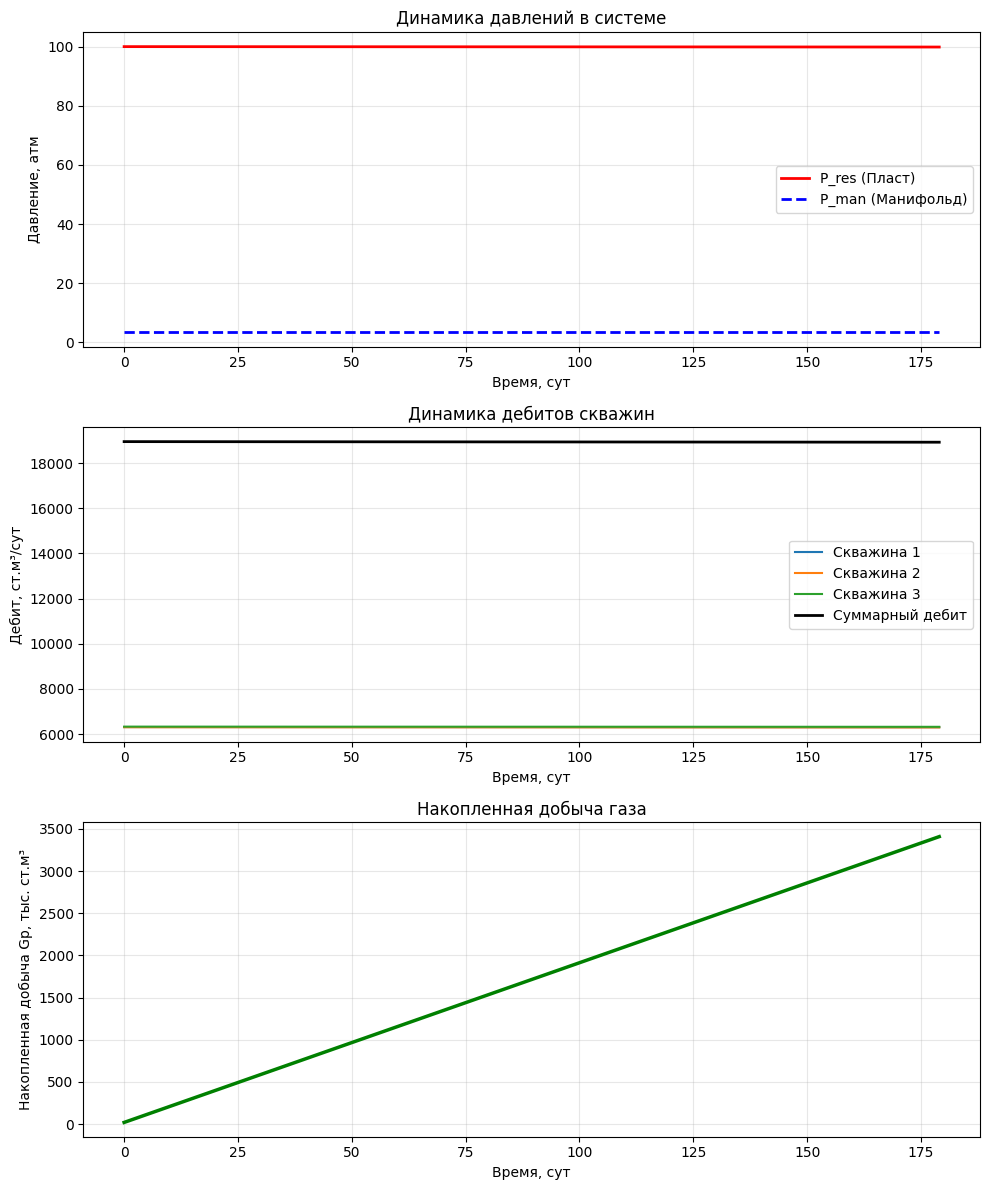

In [ ]:
# начальное давление пласта 100 атм
reservoir.resprops.P = P_res_0

# запуск симуляции на 180 дней
df_history = sim.run(N_days=180, dt=1.0) # dt=1.0 - шаг в 1 сутки

# визуализация результатов
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# график давления
axes[0].plot(df_history['t'], df_history['P_res'], 'r-', linewidth=2, label='P_res (Пласт)')
axes[0].plot(df_history['t'], df_history['P_man'], 'b--', linewidth=2, label='P_man (Манифольд)')
axes[0].set_xlabel('Время, сут')
axes[0].set_ylabel('Давление, атм')
axes[0].set_title('Динамика давлений в системе')
axes[0].grid(alpha=0.3)
axes[0].legend()

# график дебитов скважин
axes[1].plot(df_history['t'], df_history['q1'], label='Скважина 1')
axes[1].plot(df_history['t'], df_history['q2'], label='Скважина 2')
axes[1].plot(df_history['t'], df_history['q3'], label='Скважина 3')
axes[1].plot(df_history['t'], df_history['q_total'], 'k-', linewidth=2, label='Суммарный дебит')
axes[1].set_xlabel('Время, сут')
axes[1].set_ylabel('Дебит, ст.м³/сут')
axes[1].set_title('Динамика дебитов скважин')
axes[1].grid(alpha=0.3)
axes[1].legend()

# график накопленной добычи
axes[2].plot(df_history['t'], df_history['Gp'], 'g-', linewidth=2.5)
axes[2].set_xlabel('Время, сут')
axes[2].set_ylabel('Накопленная добыча Gp, тыс. ст.м³')
axes[2].set_title('Накопленная добыча газа')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

При заданных параметрах пласта (19.6 млн м³) и начальном давлении 100 атм, отбор газа в объёме 3.4 млн м³ за 180 дней приводит к незначительному падению пластового давления. Чтобы убедиться, что давление снижается и симулятор работает правильно, выведу более точные значения

In [ ]:
print(f"{'День':<6} | {'P_res, атм':<15} | {'ΔP, атм':<15}")
print("-" * 40)

for day in [0, 30, 60, 90, 120, 150, 180]:
    if day < len(df_history):
        p_res = df_history['P_res'].iloc[day]
        delta_p = p_res - P_res_0
        print(f"{day:<6} | {p_res:<15.8f} | {delta_p:<15.8f}")

p_final = df_history['P_res'].iloc[-1]
print(f"\nИтоговое падение давления за 180 дней: {P_res_0 - p_final:.8f} атм")

День   | P_res, атм      | ΔP, атм        
----------------------------------------
0      | 100.00000000    | 0.00000000     
30     | 99.97687519     | -0.02312481    
60     | 99.95375455     | -0.04624545    
90     | 99.93063807     | -0.06936193    
120    | 99.90752577     | -0.09247423    
150    | 99.88441763     | -0.11558237    

Итоговое падение давления за 180 дней: 0.13791628 атм


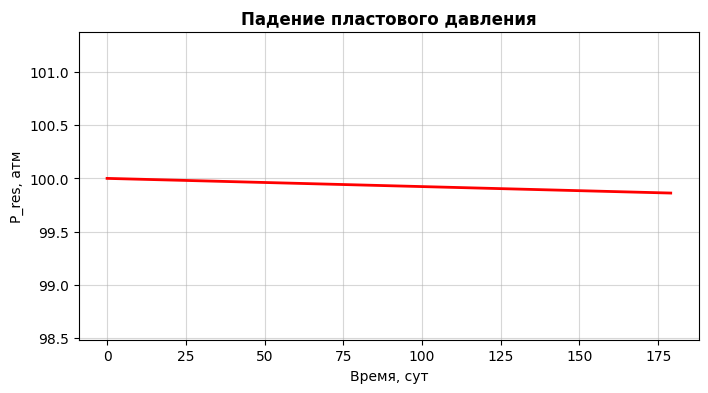

In [ ]:
# чтобы наглядно показать падение пластового давления, создам новый график с приближением
plt.figure(figsize=(8, 4))
plt.plot(df_history['t'], df_history['P_res'], 'r-', linewidth=2)
plt.title('Падение пластового давления', fontweight='bold')
plt.xlabel('Время, сут')
plt.ylabel('P_res, атм')

# пределы оси Y
p_min = df_history['P_res'].min()
p_max = df_history['P_res'].max()
margin = (p_max - p_min) * 10  # увеличиваем масштаб в 10 раз
plt.ylim(p_min - margin, p_max + margin)

plt.grid(alpha=0.5)
plt.show()

Также интересно посмотреть, как будет изменяться давление за время разработки месторождения. Возьму произвольно 25 лет и буду отображать результаты каждый год

Начальное давление: 100.0 атм
Day   0/9125 | P_res: 100.00 атм
Day  10/9125 | P_res: 99.99 атм
Day  20/9125 | P_res: 99.98 атм
Day  30/9125 | P_res: 99.98 атм
Day  40/9125 | P_res: 99.97 атм
Day  50/9125 | P_res: 99.96 атм
Day  60/9125 | P_res: 99.95 атм
Day  70/9125 | P_res: 99.95 атм
Day  80/9125 | P_res: 99.94 атм
Day  90/9125 | P_res: 99.93 атм
Day 100/9125 | P_res: 99.92 атм
Day 110/9125 | P_res: 99.92 атм
Day 120/9125 | P_res: 99.91 атм
Day 130/9125 | P_res: 99.90 атм
Day 140/9125 | P_res: 99.89 атм
Day 150/9125 | P_res: 99.88 атм
Day 160/9125 | P_res: 99.88 атм
Day 170/9125 | P_res: 99.87 атм
Day 180/9125 | P_res: 99.86 атм
Day 190/9125 | P_res: 99.85 атм
Day 200/9125 | P_res: 99.85 атм
Day 210/9125 | P_res: 99.84 атм
Day 220/9125 | P_res: 99.83 атм
Day 230/9125 | P_res: 99.82 атм
Day 240/9125 | P_res: 99.82 атм
Day 250/9125 | P_res: 99.81 атм
Day 260/9125 | P_res: 99.80 атм
Day 270/9125 | P_res: 99.79 атм
Day 280/9125 | P_res: 99.78 атм
Day 290/9125 | P_res: 99.78 атм
Day 300/9

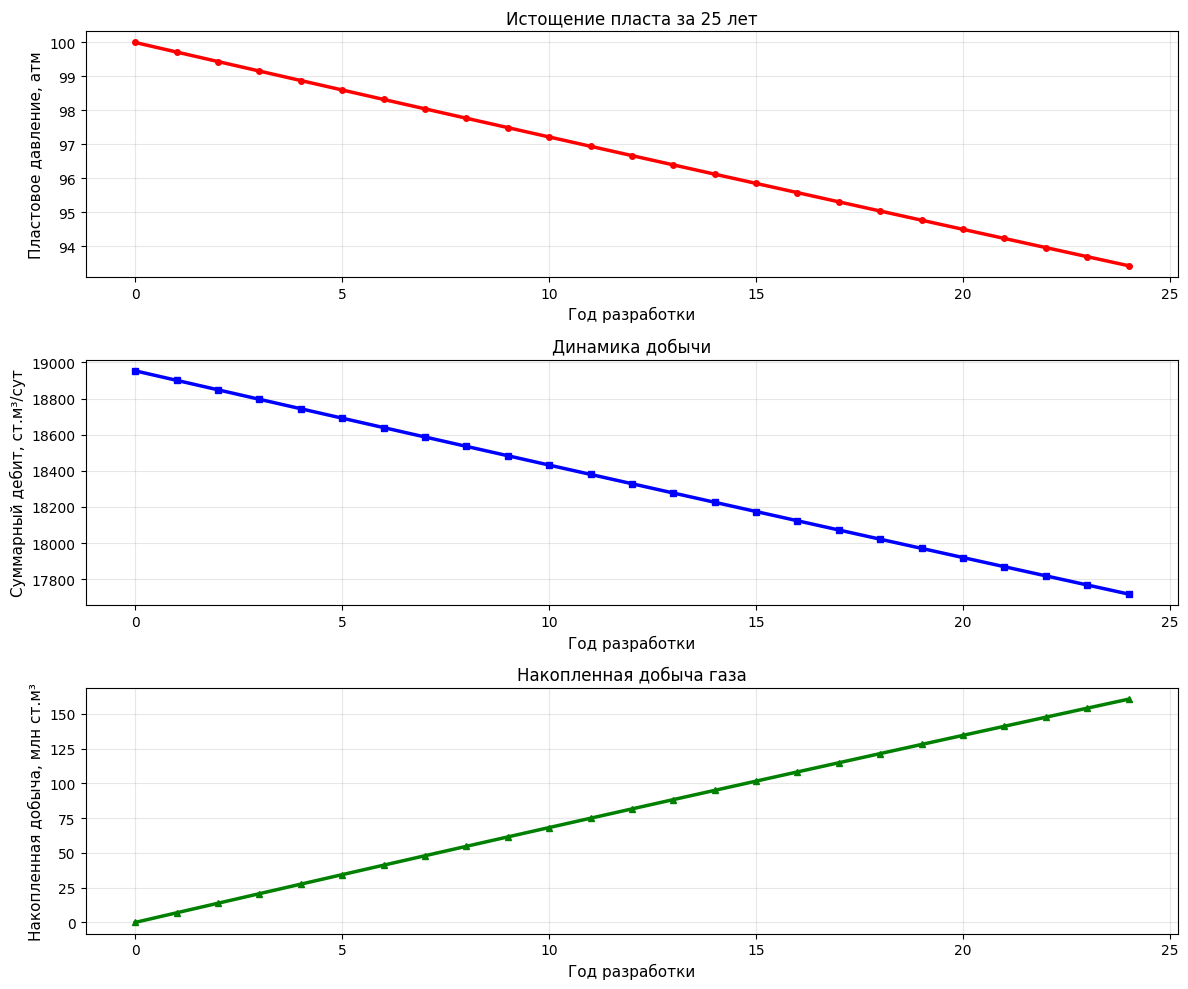

In [ ]:
reservoir.resprops.P = 100.0
N_years = 25
days_per_year = 365
total_days = N_years * days_per_year

print(f"Начальное давление: {reservoir.resprops.P} атм")

df_long = sim.run(N_days=total_days, dt=1.0)

print("Симуляция завершена!")

# анализ результатов по годам
print(f"{'Год':<6} | {'День':<8} | {'P_res, атм':<12} | {'q_total, м³/сут':<16} | {'Gp, млн м³':<12}")
print("-"*85)

yearly_data = []
for year in range(N_years + 1):
    day = year * days_per_year
    if day < len(df_long):
        row = df_long.iloc[day]
        p_res = row['P_res']
        q_total = row['q_total']
        gp = row['Gp'] / 1000  # переводим из тыс. в млн м³

        yearly_data.append({
            'year': year,
            'day': day,
            'P_res': p_res,
            'q_total': q_total,
            'Gp': gp
        })

        print(f"{year:<6} | {day:<8} | {p_res:<12.4f} | {q_total:<16.1f} | {gp:<12.2f}")

# итоговые изменения
p_start = yearly_data[0]['P_res']
p_end = yearly_data[-1]['P_res']
gp_final = yearly_data[-1]['Gp']

print(f"Итоги за {N_years} лет:")
print(f"  Падение давления: {p_start:.2f} -> {p_end:.2f} атм (ΔP = {p_start - p_end:.4f} атм)")
print(f"  Относительное падение: {(p_start - p_end)/p_start * 100:.2f}%")
print(f"  Накопленная добыча: {gp_final:.2f} млн ст.м³")
print(f"  Средний дебит: {df_long['q_total'].mean():.1f} ст.м³/сут")

# визуализация
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# график 1 - давление по годам
years = [d['year'] for d in yearly_data]
p_res_vals = [d['P_res'] for d in yearly_data]
axes[0].plot(years, p_res_vals, 'r-', linewidth=2.5, marker='o', markersize=4)
axes[0].set_xlabel('Год разработки', fontsize=11)
axes[0].set_ylabel('Пластовое давление, атм', fontsize=11)
axes[0].set_ti
a

# график 2 - дебит по годам
q_vals = [d['q_total'] for d in yearly_data]
axes[1].plot(years, q_vals, 'b-', linewidth=2.5, marker='s', markersize=4)
axes[1].set_xlabel('Год разработки', fontsize=11)
axes[1].set_ylabel('Суммарный дебит, ст.м³/сут', fontsize=11)
axes[1].set_title('Динамика добычи', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(0, N_years+1, 5))

# график 3 - накопленная добыча
gp_vals = [d['Gp'] for d in yearly_data]
axes[2].plot(years, gp_vals, 'g-', linewidth=2.5, marker='^', markersize=4)
axes[2].set_xlabel('Год разработки', fontsize=11)
axes[2].set_ylabel('Накопленная добыча, млн ст.м³', fontsize=11)
axes[2].set_title('Накопленная добыча газа', fontsize=12)
axes[2].grid(alpha=0.3)
axes[2].set_xticks(range(0, N_years+1, 5))

plt.tight_layout()
plt.show()

## Влияние ДКС

In [35]:
# параметры симуляции
total_days = 25 * 365
CR_values = [1.0, 1.5, 2.0, 3.0]
colors = ['blue', 'green', 'orange', 'red']
labels = [f'CR = {cr}' for cr in CR_values]

results = {}

print(f"Запуск 4 симуляций на {total_days} дней")
for i, CR_test in enumerate(CR_values):
    print(f"[{i+1}/4] CR = {CR_test}...")

    reservoir.resprops.P = 100.0
    dcs_test = DCS(CR=CR_test, P_line=P_line, q_ext=q_ext) # новый объект ДКС с тестовым CR
    sim_test = FieldSimulator( # симулятор с новым ДКС
        reservoir=reservoir,
        wells=wells,
        shlyf=shlyf,
        dcs=dcs_test
    )
    df_test = sim_test.run(N_days=total_days, dt=1.0)
    results[CR_test] = {
        'df': df_test,
        'P_res_final': df_test['P_res'].iloc[-1],
        'Gp_final': df_test['Gp'].iloc[-1],
        'q_avg': df_test['q_total'].mean()
    }

    print(f"Завершено: P_res={results[CR_test]['P_res_final']:.4f} атм, "
          f"Gp={results[CR_test]['Gp_final']:.1f} млн м³")

print("Симуляции завершены!")

Запуск 4 симуляций на 9125 дней
[1/4] CR = 1.0...
Day   0/9125 | P_res: 100.00 атм
Day  10/9125 | P_res: 99.99 атм
Day  20/9125 | P_res: 99.98 атм
Day  30/9125 | P_res: 99.98 атм
Day  40/9125 | P_res: 99.97 атм
Day  50/9125 | P_res: 99.96 атм
Day  60/9125 | P_res: 99.95 атм
Day  70/9125 | P_res: 99.95 атм
Day  80/9125 | P_res: 99.94 атм
Day  90/9125 | P_res: 99.93 атм
Day 100/9125 | P_res: 99.92 атм
Day 110/9125 | P_res: 99.92 атм
Day 120/9125 | P_res: 99.91 атм
Day 130/9125 | P_res: 99.90 атм
Day 140/9125 | P_res: 99.89 атм
Day 150/9125 | P_res: 99.89 атм
Day 160/9125 | P_res: 99.88 атм
Day 170/9125 | P_res: 99.87 атм
Day 180/9125 | P_res: 99.86 атм
Day 190/9125 | P_res: 99.86 атм
Day 200/9125 | P_res: 99.85 атм
Day 210/9125 | P_res: 99.84 атм
Day 220/9125 | P_res: 99.83 атм
Day 230/9125 | P_res: 99.83 атм
Day 240/9125 | P_res: 99.82 атм
Day 250/9125 | P_res: 99.81 атм
Day 260/9125 | P_res: 99.80 атм
Day 270/9125 | P_res: 99.80 атм
Day 280/9125 | P_res: 99.79 атм
Day 290/9125 | P_res:

In [36]:
print(f"{'CR':<6} | {'P_res (кон.), атм':<18} | {'ΔP, атм':<10} | {'Gp, млн м³':<14} | {'Средний q, м³/сут':<18}")
print("-"*90)

for CR_test in CR_values:
    r = results[CR_test]
    delta_p = 100.0 - r['P_res_final']
    print(f"{CR_test:<6} | {r['P_res_final']:<18.4f} | {delta_p:<10.2f} | "
          f"{r['Gp_final']/1000:<14.2f} | {r['q_avg']:<18.2f}")

CR     | P_res (кон.), атм  | ΔP, атм    | Gp, млн м³     | Средний q, м³/сут 
------------------------------------------------------------------------------------------
1.0    | 93.2822            | 6.72       | 164.01         | 17973.83          
1.5    | 93.1572            | 6.84       | 167.04         | 18305.75          
2.0    | 93.0985            | 6.90       | 168.46         | 18461.75          
3.0    | 93.0452            | 6.95       | 169.75         | 18603.17          


Можно заметить, что рост CR снижает давление на манифольде и увеличивает начальную депрессию. Накопленная добыча растет, но с убывающей отдачей. Таким образом, мы получаем больший начальный дебит, но ускоряем истощение.

В нашем примере высокая рабочая депрессия, поэтому снижение противодавления на манифольде малозаметно изменяет общую движущую силу и результаты получаются схожими. Однако правильные тенденции заметны и при таких исходных данных.

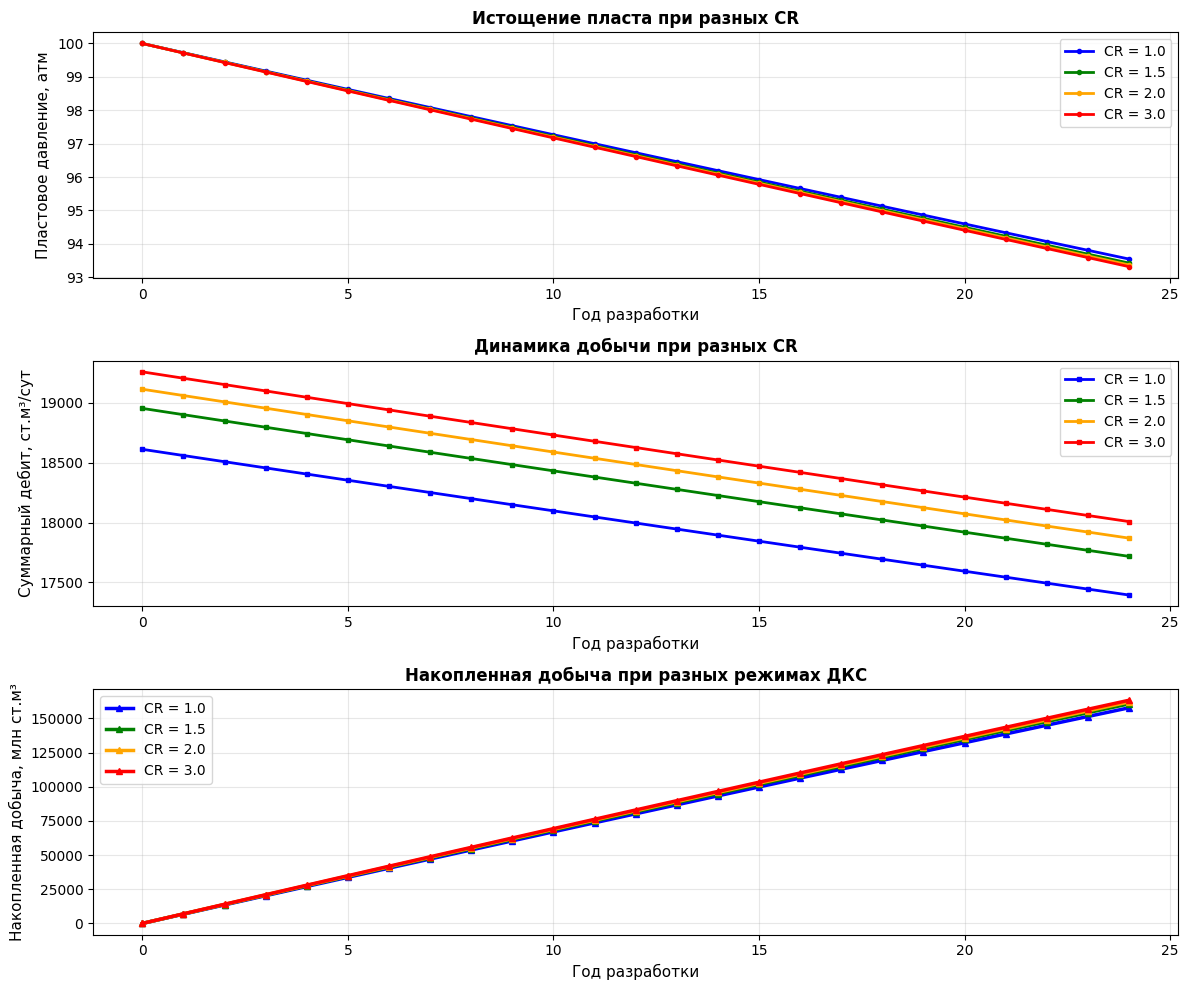

In [39]:
N_years = 25
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
years = np.arange(0, N_years + 1)

# график пластового давления
for CR_test, color, label in zip(CR_values, colors, labels):
    df = results[CR_test]['df']
    p_vals = [df.iloc[year*365]['P_res'] if year*365 < len(df) else np.nan
              for year in years]
    axes[0].plot(years, p_vals, color=color, linewidth=2, label=label, marker='o', markersize=3)

axes[0].set_xlabel('Год разработки', fontsize=11)
axes[0].set_ylabel('Пластовое давление, атм', fontsize=11)
axes[0].set_title('Истощение пласта при разных CR', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(0, N_years+1, 5))

# график суммарного дебита
for CR_test, color, label in zip(CR_values, colors, labels):
    df = results[CR_test]['df']
    q_vals = [df.iloc[year*365]['q_total'] if year*365 < len(df) else np.nan
              for year in years]
    axes[1].plot(years, q_vals, color=color, linewidth=2, label=label, marker='s', markersize=3)

axes[1].set_xlabel('Год разработки', fontsize=11)
axes[1].set_ylabel('Суммарный дебит, ст.м³/сут', fontsize=11)
axes[1].set_title('Динамика добычи при разных CR', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(0, N_years+1, 5))

# график накопленной добычи
for CR_test, color, label in zip(CR_values, colors, labels):
    df = results[CR_test]['df']
    gp_vals = [df.iloc[year*365]['Gp'] if year*365 < len(df) else np.nan
               for year in years]
    axes[2].plot(years, gp_vals, color=color, linewidth=2.5, label=label, marker='^', markersize=4)

axes[2].set_xlabel('Год разработки', fontsize=11)
axes[2].set_ylabel('Накопленная добыча, млн ст.м³', fontsize=11)
axes[2].set_title('Накопленная добыча при разных режимах ДКС', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=10)
axes[2].set_xticks(range(0, N_years+1, 5))

plt.tight_layout()
plt.show()


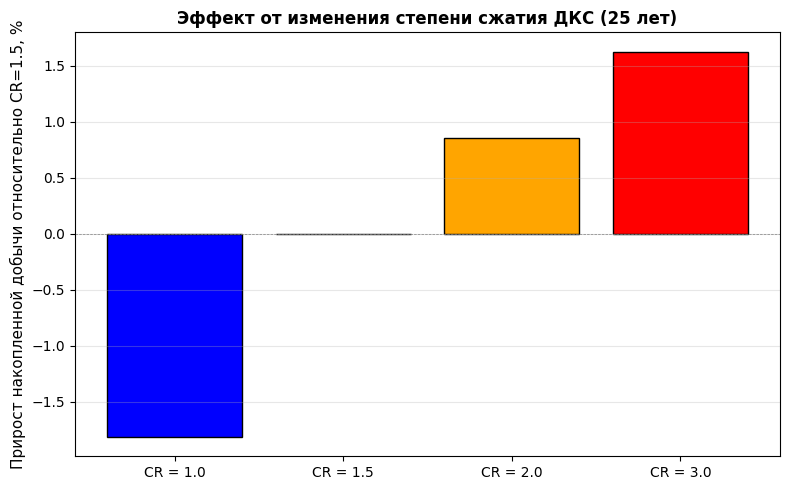

In [44]:
# прирост добычи относительно базового варианта CR=1.5
plt.figure(figsize=(8, 5))
baseline_gp = results[1.5]['Gp_final']
for CR_test, color, label in zip(CR_values, colors, labels):
    gp = results[CR_test]['Gp_final']
    gain = (gp - baseline_gp) / baseline_gp * 100
    plt.bar(label, gain, color=color, edgecolor='black')

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.ylabel('Прирост накопленной добычи относительно CR=1.5, %', fontsize=11)
plt.title('Эффект от изменения степени сжатия ДКС (25 лет)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Калибровка

In [50]:
df_adapt

,well,date,q,p_res,p_bhp,p_thp
0,1013,01.08.1900,62290,8.0709,5.3740,3.7756
1,1013,01.08.1900,30149,8.0709,6.9235,6.2076
2,1013,01.08.1900,43520,8.0709,6.3057,5.2269
3,1013,01.08.1900,66510,8.0709,5.0995,3.2852


In [59]:
# оцениваю диапазонов (важно для понимания масштаба C)
delta_P = df_adapt['p_res'] - df_adapt['p_bhp']
print(f"Диапазоны данных:")
print(f"Дебит q: {df_adapt['q'].min():.0f} – {df_adapt['q'].max():.0f} ст.м³/сут (среднее {df_adapt['q'].mean():.0f})")
print(f"Депрессия ΔP: {delta_P.min():.2f} – {delta_P.max():.2f} атм (среднее {delta_P.mean():.2f})")

Диапазоны данных:
Дебит q: 30149 – 66510 ст.м³/сут (среднее 50617)
Депрессия ΔP: 1.15 – 2.97 атм (среднее 2.15)


In [61]:
# считает, какой дебит должен быть по формуле q = C * (Pres - Pbhp)
# давление на забое не может быть выше пластового давления, поэтому с помощью maximum перестраховываюсь
def model_q(C, dP):
    return C * np.maximum(dP, 0.0)

# оцениваем по формуле RMSE
# берем текущий C, считаем модельный дебит, вычитаем факт и считаем метрику
def objective(C, dP, q_fact): # целевая функция
    return np.sqrt(np.mean((model_q(C[0], dP) - q_fact) ** 2))

In [62]:
dP_fact = delta_P.values
q_fact = df_adapt['q'].values

# начальное предположение - берем средний дебит и делим на среднюю депрессию
C0 = [np.mean(q_fact) / np.mean(dP_fact)]
print(f"Начальное приближение: C₀ = {C0[0]:.2f} ст.м³/(сут·атм)")

Начальное приближение: C₀ = 23595.31 ст.м³/(сут·атм)


In [71]:
# запуск оптимизации - минимизируем функцию objective, передаем начальную точку
# и данные, которые передаются в формулу ошибки
result = minimize(objective, C0, args=(dP_fact, q_fact),
                  method='Nelder-Mead')

C_opt = result.x[0] # найденный минимум ошибки
print(f"Оптимальное значение: C = {C_opt:.2f} ст.м³/(сут·атм)")
print(f"Статус: {result.message}")

Оптимальное значение: C = 23230.26 ст.м³/(сут·атм)
Статус: Optimization terminated successfully.


In [65]:
# оценка качества найденного решения
q_model = model_q(C_opt, dP_fact)
rmse = np.sqrt(mean_squared_error(q_fact, q_model))
r2 = r2_score(q_fact, q_model)
mape = np.mean(np.abs((q_fact - q_model) / q_fact)) * 100

print(f"Метрики качества:")
print(f'  R²   = {r2:.4f}')
print(f'  RMSE = {rmse:.0f} ст.м³/сут ({rmse/np.mean(q_fact)*100:.1f}% от среднего)')
print(f'  MAPE = {mape:.1f}%')

Метрики качества:
  R²   = 0.9709
  RMSE = 2500 ст.м³/сут (4.9% от среднего)
  MAPE = 5.4%


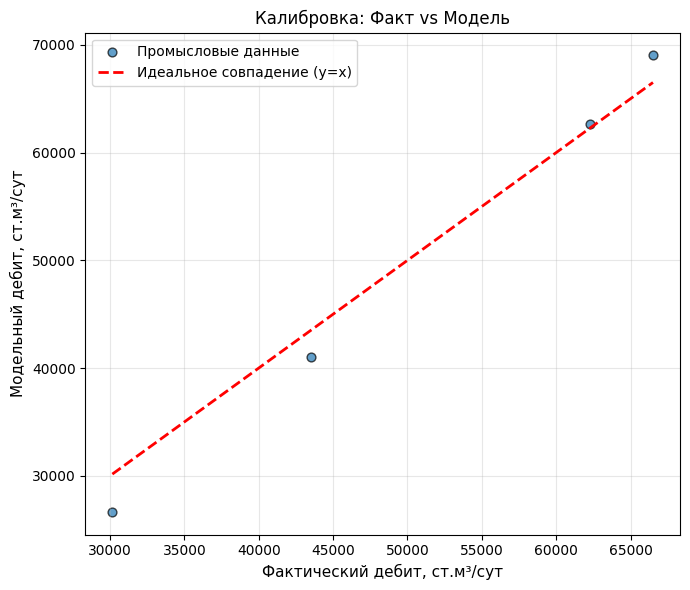

In [70]:
# график сопоставления факта с моделью
plt.figure(figsize=(7, 6))
plt.scatter(q_fact, q_model, alpha=0.7, edgecolors='black', s=40, label='Промысловые данные')
plt.plot([q_fact.min(), q_fact.max()], [q_fact.min(), q_fact.max()],
         'r--', linewidth=2, label='Идеальное совпадение (y=x)')
plt.xlabel('Фактический дебит, ст.м³/сут', fontsize=11)
plt.ylabel('Модельный дебит, ст.м³/сут', fontsize=11)
plt.title("Калибровка: Факт vs Модель")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()